# Ensemble Weight Optimisation via Tree-Structured Parzen Estimator

This notebook evaluates multiple objective function formulations for TPE-based ensemble
weight optimisation on a medical image classification task. Candidate formulations are
generated automatically from a combinatorial search over a predefined set of evaluation
metrics and coefficient pools, enabling a systematic comparison without manual specification.

The generation pipeline proceeds as follows:

1. Define a **metric pool** (`recall`, `acc`, `f1`, `auc`, `precision`) and a
   **coefficient pool** (multiples of 0.1 that sum to 1.0).
2. Enumerate all valid (metric subset, coefficient assignment) pairs.
3. Apply diversity filters: enforce a minimum number of unique metrics and remove dominated objectives.
4. Assign deterministic random seeds and per-objective trial budgets.

Ensemble weights are optimised exclusively on the **validation split**.
DS1 and DS2 are reserved for final held-out evaluation only.

### Improvements in this version

| # | Change | Rationale |
|---|--------|-----------|
| 1 | **No global `np.random.seed()` before the loop** | Prevents execution-order dependency; each study is seeded only by its own `BASE_SEED + idx` passed to `TPESampler`. |
| 2 | **Per-objective seed reset** (`random.seed` + `np.random.seed` inside loop) | Guarantees identical results regardless of which objectives ran before. |
| 3 | **`n_startup_trials` raised from 20 → 50** | 10 % of the 500-trial budget; gives TPE a more thorough random-exploration phase before exploitation begins. |
| 4 | **2-D probability array guard in `make_objective`** | `ensemble_probs` can return shape `(N, 2)`; `[:, 1]` now extracted before passing to `roc_auc_score`. |


## 1. Dependencies


In [1]:
import subprocess, sys

required = ['optuna', 'scikit-learn', 'matplotlib', 'seaborn', 'pandas', 'numpy']
for pkg in required:
    subprocess.check_call(
        [sys.executable, '-m', 'pip', 'install', pkg, '-q'],
        stdout=subprocess.DEVNULL,
        stderr=subprocess.DEVNULL,
    )
print('All packages verified.')


All packages verified.


## 2. Imports


In [2]:
import json
import warnings
import random
from pathlib import Path

warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from IPython.display import display

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
)

import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

# GLOBAL_SEED is defined here for reference only.
# It is NOT applied as a global NumPy/Python RNG seed — doing so would make
# each objective's results depend on how many objectives ran before it.
# Instead, each TPE study receives its own seed (BASE_SEED + idx) directly
# via TPESampler(seed=...), and the RNG state is reset per-objective in the loop.
GLOBAL_SEED = 42



plt.rcParams.update({
    'font.family'      : 'serif',
    'axes.spines.top'  : False,
    'axes.spines.right': False,
    'axes.grid'        : True,
    'grid.alpha'       : 0.3,
})

print('Imports ready.')


Imports ready.


## 3. Configuration


In [3]:
BASE_DIR = Path(r'D:\Tree-Structured Parzen Estimator\main')

RESULTS = {
    'densenet121' : BASE_DIR / 'densenet121'  / 'full_pipeline_results',
    'inception_v3': BASE_DIR / 'inceptionv3'  / 'full_pipeline_results',
    'xception'    : BASE_DIR / 'xception'     / 'full_pipeline_results',
    'vit_scratch' : BASE_DIR / 'vit'          / 'full_pipeline_results',
}

OUTPUT_DIR = BASE_DIR / 'testing_variabel' / 'output_test_variabel'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

MODEL_KEYS = ['densenet121', 'inception_v3', 'xception', 'vit_scratch']
MODEL_LABELS = {
    'densenet121' : 'DenseNet-121',
    'inception_v3': 'InceptionV3',
    'xception'    : 'Xception',
    'vit_scratch' : 'ViT-Pretrained',
}

# Number of objective formulations to evaluate.
N_OBJECTIVES = 20

# Total TPE trial budget, divided equally across all objectives.
# Example: TOTAL_TRIALS=10000, N_OBJECTIVES=20 → 500 trials per objective.
TOTAL_TRIALS = 10000

# Available evaluation metrics; order determines assignment priority.
# Placing 'recall' first biases composite objectives toward higher recall weight.
METRIC_POOL = ['recall', 'acc', 'f1', 'auc', 'precision']

# Valid coefficient values (multiples of 0.1; must sum to 1.0 per objective).
COEF_POOL = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0]

# Metric count per objective (1 = single-metric baseline, 4 = composite).
MIN_METRICS = 1
MAX_METRICS = 4

# Minimum coefficient per metric term.
MIN_COEF = 0.1

# Base seed passed to TPESampler; objective i uses BASE_SEED + i.
# No global np.random.seed() is set — each study is fully self-contained.
BASE_SEED = 42

# ── Sanity check ─────────────────────────────────────────────────────────────
trials_per_obj = TOTAL_TRIALS // N_OBJECTIVES
print('Configuration loaded.')
print(f'  BASE_DIR        : {BASE_DIR}')
print(f'  OUTPUT_DIR      : {OUTPUT_DIR}')
print(f'  N_OBJECTIVES    : {N_OBJECTIVES}')
print(f'  TOTAL_TRIALS    : {TOTAL_TRIALS}  ({trials_per_obj} per objective)')
print(f'  Metric pool     : {METRIC_POOL}')
print(f'  MIN_COEF        : {MIN_COEF}')
print(f'  Metrics/obj     : {MIN_METRICS}–{MAX_METRICS}')
print()
all_ok = True
for arch, path in RESULTS.items():
    ok = path.exists()
    if not ok:
        all_ok = False
    status = 'OK' if ok else 'NOT FOUND'
    print(f'  {MODEL_LABELS[arch]:<16} [{status}]  {path}')
print()
if all_ok:
    print('All result directories found.')
else:
    print('WARNING: one or more result directories are missing.')


Configuration loaded.
  BASE_DIR        : D:\Tree-Structured Parzen Estimator\main
  OUTPUT_DIR      : D:\Tree-Structured Parzen Estimator\main\testing_variabel\output_test_variabel
  N_OBJECTIVES    : 20
  TOTAL_TRIALS    : 10000  (500 per objective)
  Metric pool     : ['recall', 'acc', 'f1', 'auc', 'precision']
  MIN_COEF        : 0.1
  Metrics/obj     : 1–4

  DenseNet-121     [OK]  D:\Tree-Structured Parzen Estimator\main\densenet121\full_pipeline_results
  InceptionV3      [OK]  D:\Tree-Structured Parzen Estimator\main\inceptionv3\full_pipeline_results
  Xception         [OK]  D:\Tree-Structured Parzen Estimator\main\xception\full_pipeline_results
  ViT-Pretrained   [OK]  D:\Tree-Structured Parzen Estimator\main\vit\full_pipeline_results

All result directories found.


## 3b. Automatic Objective Generation

The cell below replaces a static objective dictionary with a generator that
programmatically enumerates all valid metric–coefficient combinations.
Modifying `N_OBJECTIVES`, `METRIC_POOL`, or `COEF_POOL` in Cell 3 is sufficient
to produce a completely different set of formulations without any further manual editing.


In [4]:
from itertools import combinations, product as iproduct


def _fmt_label(weights: dict) -> str:
    name_map = {
        'acc': 'Acc', 'recall': 'Recall',
        'precision': 'Prec', 'f1': 'F1', 'auc': 'AUC',
    }
    return ' + '.join(f'{c} x {name_map[m]}' for m, c in weights.items())


def generate_objectives(
    metric_pool  : list,
    coef_pool    : list,
    min_metrics  : int   = 1,
    max_metrics  : int   = 4,
    min_coef     : float = 0.1,
    n_select     : int   = 10,
    base_seed    : int   = 42,
    total_trials : int   = 1000,
) -> dict:
    """
    Enumerate all valid composite objectives, apply diversity filters,
    and return the top `n_select` as an ordered dict ready for TPE optimisation.

    Trial budget
    ------------
    Each objective receives an equal share: trials_per_obj = total_trials // n_select.
    This ensures a fair comparison across all formulations.

    Selection heuristic (applied in order)
    --------------------------------------
    1. Single-metric baselines (one per metric) — always included.
    2. Composites with the highest recall and AUC coverage.
    3. Composites with the greatest number of unique metrics (diversity).
    4. Remaining slots filled lexicographically for full reproducibility.

    Parameters
    ----------
    metric_pool  : Metrics available for combination. Order encodes assignment priority.
    coef_pool    : Valid coefficient values.
    min_metrics  : Minimum number of metrics per objective.
    max_metrics  : Maximum number of metrics per objective.
    min_coef     : Minimum coefficient for any metric term.
    n_select     : Number of objectives to return.
    base_seed    : Seed for the first objective; objective i uses base_seed + i.
    total_trials : Total trial budget divided equally across all objectives.

    Returns
    -------
    dict  Mapping OBJ-01 … OBJ-N to dicts with keys: label, weights, seed, trials.
    """
    PRIORITY_METRICS = {'recall', 'auc'}
    trials_per_obj   = total_trials // n_select

    candidates = []
    seen_keys  = set()

    for n in range(min_metrics, max_metrics + 1):
        for metric_combo in combinations(metric_pool, n):
            if n == 1:
                coef_combos = [(1.0,)]
            else:
                coef_combos = [
                    coefs
                    for coefs in iproduct(coef_pool, repeat=n)
                    if (
                        abs(sum(coefs) - 1.0) < 1e-9
                        and coefs == tuple(sorted(coefs, reverse=True))
                        and min(coefs) >= min_coef
                    )
                ]

            for coefs in coef_combos:
                sorted_metrics = sorted(
                    metric_combo,
                    key=lambda m: (m in PRIORITY_METRICS, metric_pool.index(m)),
                    reverse=True,
                )
                weights = dict(zip(sorted_metrics, sorted(coefs, reverse=True)))

                key = frozenset(weights.items())
                if key in seen_keys:
                    continue
                seen_keys.add(key)

                priority = (
                    (n == 1),
                    len(set(weights) & PRIORITY_METRICS),
                    len(weights),
                    weights.get('recall', 0) + weights.get('auc', 0),
                )
                candidates.append((priority, weights))

    candidates.sort(key=lambda x: x[0], reverse=True)

    selected    = []
    seen_labels = set()
    singles     = [(p, w) for p, w in candidates if len(w) == 1]
    composites  = [(p, w) for p, w in candidates if len(w) > 1]

    for _, w in singles:
        lbl = _fmt_label(w)
        if lbl not in seen_labels:
            selected.append(w)
            seen_labels.add(lbl)

    for _, w in composites:
        if len(selected) >= n_select:
            break
        lbl = _fmt_label(w)
        if lbl not in seen_labels:
            selected.append(w)
            seen_labels.add(lbl)

    objectives = {}
    for idx, weights in enumerate(selected[:n_select]):
        obj_id = f'OBJ-{idx + 1:02d}'
        objectives[obj_id] = {
            'label'  : _fmt_label(weights),
            'weights': weights,
            'seed'   : base_seed + idx,
            'trials' : trials_per_obj,
        }
    return objectives


# ── Generate and display ──────────────────────────────────────────────────────
OBJECTIVES = generate_objectives(
    metric_pool  = METRIC_POOL,
    coef_pool    = COEF_POOL,
    min_metrics  = MIN_METRICS,
    max_metrics  = MAX_METRICS,
    min_coef     = MIN_COEF,
    n_select     = N_OBJECTIVES,
    base_seed    = BASE_SEED,
    total_trials = TOTAL_TRIALS,
)

trials_actual = sum(cfg['trials'] for cfg in OBJECTIVES.values())
print(f'{len(OBJECTIVES)} objectives generated  |  '
      f'{trials_actual} total trials  '
      f'({TOTAL_TRIALS // N_OBJECTIVES} per objective)')
print()
print(f'  {"ID":<8} {"Seed":>5} {"Trials":>7}  Formula')
print('  ' + '-' * 72)
for obj_id, cfg in OBJECTIVES.items():
    print(f'  {obj_id:<8} {cfg["seed"]:>5} {cfg["trials"]:>7}  {cfg["label"]}')
print()
print(f'  Total trials to run: {trials_actual}')


20 objectives generated  |  10000 total trials  (500 per objective)

  ID        Seed  Trials  Formula
  ------------------------------------------------------------------------
  OBJ-01      42     500  1.0 x Recall
  OBJ-02      43     500  1.0 x AUC
  OBJ-03      44     500  1.0 x Acc
  OBJ-04      45     500  1.0 x F1
  OBJ-05      46     500  1.0 x Prec
  OBJ-06      47     500  0.4 x AUC + 0.4 x Recall + 0.1 x F1 + 0.1 x Acc
  OBJ-07      48     500  0.5 x AUC + 0.3 x Recall + 0.1 x F1 + 0.1 x Acc
  OBJ-08      49     500  0.6 x AUC + 0.2 x Recall + 0.1 x F1 + 0.1 x Acc
  OBJ-09      50     500  0.4 x AUC + 0.4 x Recall + 0.1 x Prec + 0.1 x Acc
  OBJ-10      51     500  0.5 x AUC + 0.3 x Recall + 0.1 x Prec + 0.1 x Acc
  OBJ-11      52     500  0.6 x AUC + 0.2 x Recall + 0.1 x Prec + 0.1 x Acc
  OBJ-12      53     500  0.4 x AUC + 0.4 x Recall + 0.1 x Prec + 0.1 x F1
  OBJ-13      54     500  0.5 x AUC + 0.3 x Recall + 0.1 x Prec + 0.1 x F1
  OBJ-14      55     500  0.6 x AUC + 0

## 4. Load Prediction Arrays


In [5]:
PROB_FILES = {
    'densenet121' : ('probs_ds1_densenet121.npy',  'val_probs_densenet121.npy',  'probs_ds2_densenet121.npy'),
    'inception_v3': ('probs_ds1_inception_v3.npy', 'val_probs_inception_v3.npy', 'probs_ds2_inception_v3.npy'),
    'xception'    : ('probs_ds1_xception.npy',     'val_probs_xception.npy',     'probs_ds2_xception.npy'),
    'vit_scratch' : ('probs_ds1_vit_scratch.npy',  'val_probs_vit_scratch.npy',  'probs_ds2_vit_scratch.npy'),
}

all_probs_ds1 = {}
all_val_probs = {}
all_probs_ds2 = {}

print('Loading prediction arrays...')
for arch in MODEL_KEYS:
    d = RESULTS[arch]
    f_ds1, f_val, f_ds2 = PROB_FILES[arch]
    try:
        all_probs_ds1[arch] = np.load(d / f_ds1)
        all_val_probs[arch] = np.load(d / f_val)
        all_probs_ds2[arch] = np.load(d / f_ds2)
        print(
            f'  {MODEL_LABELS[arch]:<16}  '
            f'DS1={all_probs_ds1[arch].shape}  '
            f'val={all_val_probs[arch].shape}  '
            f'DS2={all_probs_ds2[arch].shape}'
        )
    except FileNotFoundError as e:
        print(f'  {MODEL_LABELS[arch]:<16}  MISSING: {e}')

ref        = RESULTS['densenet121']
ds1_labels = np.load(ref / 'ds1_labels.npy')
ds2_labels = np.load(ref / 'ds2_labels.npy')
val_labels = np.load(ref / 'val_labels.npy')

print()
print(f'  DS1 labels : {ds1_labels.shape}  (n={len(ds1_labels)})')
print(f'  DS2 labels : {ds2_labels.shape}  (n={len(ds2_labels)})')
print(f'  Val labels : {val_labels.shape}  (n={len(val_labels)})')
print(f'\n{len(all_probs_ds1)}/{len(MODEL_KEYS)} models loaded successfully.')


Loading prediction arrays...
  DenseNet-121      DS1=(2000,)  val=(1782,)  DS2=(1000,)
  InceptionV3       DS1=(2000,)  val=(1782,)  DS2=(1000,)
  Xception          DS1=(2000,)  val=(1782,)  DS2=(1000,)
  ViT-Pretrained    DS1=(2000,)  val=(1782,)  DS2=(1000,)

  DS1 labels : (2000,)  (n=2000)
  DS2 labels : (1000,)  (n=1000)
  Val labels : (1782,)  (n=1782)

4/4 models loaded successfully.


## 5. Helper Functions


In [6]:
def compute_metrics(labels, probs, threshold=0.5):
    """Compute classification metrics at a fixed decision threshold."""
    preds = (probs >= threshold).astype(int)
    try:
        auc = roc_auc_score(labels, probs)
    except Exception:
        auc = 0.0
    return {
        'accuracy'  : float(accuracy_score(labels, preds)),
        'precision' : float(precision_score(labels, preds, zero_division=0)),
        'recall'    : float(recall_score(labels, preds, zero_division=0)),
        'f1'        : float(f1_score(labels, preds, zero_division=0)),
        'auc'       : float(auc),
        'conf_mat'  : confusion_matrix(labels, preds).tolist(),
        'threshold' : float(threshold),
    }


def ensemble_probs(probs_dict, weights, keys):
    """Compute a weighted average of model probability outputs."""
    out = np.zeros_like(list(probs_dict.values())[0])
    for k, w in zip(keys, weights):
        out += w * probs_dict[k]
    return out


def make_objective(obj_weights):
    """Return an Optuna objective that maximises a weighted metric combination
    evaluated on the validation set."""
    def objective(trial):
        raw    = [trial.suggest_float(f'w_{k}', 0.05, 1.0) for k in MODEL_KEYS]
        w_norm = [r / sum(raw) for r in raw]
        probs  = ensemble_probs(all_val_probs, w_norm, MODEL_KEYS)
        # ensemble_probs may return shape (N, 2) — keep positive-class column
        if probs.ndim == 2:
            probs = probs[:, 1]
        preds  = (probs >= 0.5).astype(int)
        metric_vals = {
            'acc'      : accuracy_score(val_labels, preds),
            'recall'   : recall_score(val_labels, preds, zero_division=0),
            'precision': precision_score(val_labels, preds, zero_division=0),
            'f1'       : f1_score(val_labels, preds, zero_division=0),
        }
        try:
            metric_vals['auc'] = roc_auc_score(val_labels, probs)
        except Exception:
            metric_vals['auc'] = metric_vals['acc']
        return sum(obj_weights.get(m, 0.0) * metric_vals[m] for m in obj_weights)
    return objective


print('Helper functions defined.')


Helper functions defined.


## 6. TPE Search — All Objective Formulations

Each objective is optimised with an independent TPE study using a unique random seed,
ensuring full reproducibility. Weight search is conducted on the validation set only;
DS1 and DS2 remain unseen during optimisation and are used solely for final evaluation.


In [7]:
all_results = {}

for obj_id, cfg in OBJECTIVES.items():
    print(f'\n{"-" * 68}')
    print(f'  {obj_id}  |  {cfg["label"]}')
    print(f'  Trials: {cfg["trials"]}   Seed: {cfg["seed"]}')

    # Isolate per-objective randomness: reset NumPy/Python RNG state
    # using this objective's own seed before creating the Optuna study.
    # This ensures results are independent of execution order.
    rng_seed = cfg['seed']
    random.seed(rng_seed)
    np.random.seed(rng_seed)


    study = optuna.create_study(
        direction  = 'maximize',
        sampler    = optuna.samplers.TPESampler(
            seed                      = cfg['seed'],
            n_startup_trials          = 50,  # 10 % of 500-trial budget — more robust exploration
            multivariate              = True,
            warn_independent_sampling = False,
        ),
        study_name = obj_id,
    )
    study.optimize(
        make_objective(cfg['weights']),
        n_trials          = cfg['trials'],
        show_progress_bar = True,
    )

    raw          = [study.best_params[f'w_{k}'] for k in MODEL_KEYS]
    best_weights = [r / sum(raw) for r in raw]
    weights_dict = {k: float(w) for k, w in zip(MODEL_KEYS, best_weights)}

    ep_ds1 = ensemble_probs(all_probs_ds1, best_weights, MODEL_KEYS)
    ep_ds2 = ensemble_probs(all_probs_ds2, best_weights, MODEL_KEYS)
    m_ds1  = compute_metrics(ds1_labels, ep_ds1)
    m_ds2  = compute_metrics(ds2_labels, ep_ds2)

    all_results[obj_id] = {
        'label'     : cfg['label'],
        'best_score': float(study.best_value),
        'weights'   : weights_dict,
        'ds1'       : m_ds1,
        'ds2'       : m_ds2,
    }

    print(f'  Val score : {study.best_value:.6f}')
    print(
        f'  DS1       : Acc={m_ds1["accuracy"]:.4f}  Recall={m_ds1["recall"]:.4f}  '
        f'Prec={m_ds1["precision"]:.4f}  F1={m_ds1["f1"]:.4f}  AUC={m_ds1["auc"]:.6f}'
    )
    print(
        f'  DS2       : Acc={m_ds2["accuracy"]:.4f}  Recall={m_ds2["recall"]:.4f}  '
        f'Prec={m_ds2["precision"]:.4f}  F1={m_ds2["f1"]:.4f}  AUC={m_ds2["auc"]:.6f}'
    )
    print(
        f'  Weights   : DenseNet={weights_dict["densenet121"]:.3f}  '
        f'InceptionV3={weights_dict["inception_v3"]:.3f}  '
        f'Xception={weights_dict["xception"]:.3f}  '
        f'ViT={weights_dict["vit_scratch"]:.3f}'
    )

    obj_dir = OUTPUT_DIR / obj_id
    obj_dir.mkdir(parents=True, exist_ok=True)
    with open(obj_dir / 'weights.json', 'w') as fh:
        json.dump(weights_dict, fh, indent=2)

print(f'\n{"=" * 68}')
print(f'All {N_OBJECTIVES} objectives completed.')



--------------------------------------------------------------------
  OBJ-01  |  1.0 x Recall
  Trials: 500   Seed: 42


  0%|          | 0/500 [00:00<?, ?it/s]

  Val score : 0.926103
  DS1       : Acc=0.9590  Recall=0.9580  Prec=0.9599  F1=0.9590  AUC=0.993711
  DS2       : Acc=0.9710  Recall=0.9720  Prec=0.9701  F1=0.9710  AUC=0.994840
  Weights   : DenseNet=0.414  InceptionV3=0.044  Xception=0.229  ViT=0.312

--------------------------------------------------------------------
  OBJ-02  |  1.0 x AUC
  Trials: 500   Seed: 43


  0%|          | 0/500 [00:00<?, ?it/s]

  Val score : 0.982924
  DS1       : Acc=0.9625  Recall=0.9480  Prec=0.9763  F1=0.9619  AUC=0.993878
  DS2       : Acc=0.9760  Recall=0.9700  Prec=0.9818  F1=0.9759  AUC=0.997180
  Weights   : DenseNet=0.040  InceptionV3=0.357  Xception=0.044  ViT=0.558

--------------------------------------------------------------------
  OBJ-03  |  1.0 x Acc
  Trials: 500   Seed: 44


...

  Val score : 0.952151
  DS1       : Acc=0.9620  Recall=0.9590  Prec=0.9648  F1=0.9619  AUC=0.994128
  DS2       : Acc=0.9740  Recall=0.9680  Prec=0.9798  F1=0.9738  AUC=0.996140
  Weights   : DenseNet=0.192  InceptionV3=0.217  Xception=0.210  ViT=0.382

--------------------------------------------------------------------
  OBJ-19  |  0.5 x AUC + 0.2 x Recall + 0.2 x F1 + 0.1 x Acc
  Trials: 500   Seed: 60


  0%|          | 0/500 [00:00<?, ?it/s]

  Val score : 0.957550
  DS1       : Acc=0.9620  Recall=0.9590  Prec=0.9648  F1=0.9619  AUC=0.994202
  DS2       : Acc=0.9750  Recall=0.9700  Prec=0.9798  F1=0.9749  AUC=0.996228
  Weights   : DenseNet=0.202  InceptionV3=0.247  Xception=0.203  ViT=0.349

--------------------------------------------------------------------
  OBJ-20  |  0.4 x AUC + 0.3 x Recall + 0.2 x Prec + 0.1 x Acc
  Trials: 500   Seed: 61


  0%|          | 0/500 [00:00<?, ?it/s]

  Val score : 0.954198
  DS1       : Acc=0.9620  Recall=0.9590  Prec=0.9648  F1=0.9619  AUC=0.994095
  DS2       : Acc=0.9740  Recall=0.9680  Prec=0.9798  F1=0.9738  AUC=0.996064
  Weights   : DenseNet=0.183  InceptionV3=0.220  Xception=0.226  ViT=0.371

All 20 objectives completed.


## 7. Results Table


In [8]:
rows = []
for obj_id, res in all_results.items():
    d1, d2 = res['ds1'], res['ds2']
    rows.append({
        'ID'           : obj_id,
        'Formula'      : res['label'],
        'DS1 Accuracy' : round(d1['accuracy'],  4),
        'DS1 Recall'   : round(d1['recall'],    4),
        'DS1 Precision': round(d1['precision'], 4),
        'DS1 F1'       : round(d1['f1'],        4),
        'DS1 AUC'      : round(d1['auc'],       4),
        'DS2 Accuracy' : round(d2['accuracy'],  4),
        'DS2 Recall'   : round(d2['recall'],    4),
        'DS2 F1'       : round(d2['f1'],        4),
        'DS2 AUC'      : round(d2['auc'],       4),
    })

df = pd.DataFrame(rows).set_index('ID')

print('=' * 110)
print('  Objective Function Comparison — DS1 Test Set + DS2 Cross-Dataset Evaluation')
print('=' * 110)
display(df)

df.to_csv(OUTPUT_DIR / 'objective_comparison.csv')
print(f'\nSaved: {OUTPUT_DIR / "objective_comparison.csv"}')

print()
print('Best objective per metric (DS1):')
for col in ['DS1 Accuracy', 'DS1 Recall', 'DS1 F1', 'DS1 AUC']:
    idx = df[col].idxmax()
    print(f'  {col:<16}  {idx}  ({df.loc[idx, col]:.4f})  —  {all_results[idx]["label"]}')

print()
print('Best objective per metric (DS2):')
for col in ['DS2 Accuracy', 'DS2 Recall', 'DS2 F1', 'DS2 AUC']:
    idx = df[col].idxmax()
    print(f'  {col:<16}  {idx}  ({df.loc[idx, col]:.4f})  —  {all_results[idx]["label"]}')


  Objective Function Comparison — DS1 Test Set + DS2 Cross-Dataset Evaluation


,Formula,DS1 Accuracy,DS1 Recall,DS1 Precision,DS1 F1,DS1 AUC,DS2 Accuracy,DS2 Recall,DS2 F1,DS2 AUC
ID,,,,,,,,,,
OBJ-01,1.0 x Recall,0.9590,0.958,0.9599,0.9590,0.9937,0.971,0.972,0.9710,0.9948
OBJ-02,1.0 x AUC,0.9625,0.948,0.9763,0.9619,0.9939,0.976,0.970,0.9759,0.9972
OBJ-03,1.0 x Acc,0.9625,0.959,0.9658,0.9624,0.9941,0.974,0.968,0.9738,0.9961
OBJ-04,1.0 x F1,0.9620,0.959,0.9648,0.9619,0.9942,0.975,0.970,0.9749,0.9962
OBJ-05,1.0 x Prec,0.9585,0.952,0.9645,0.9582,0.9936,0.974,0.972,0.9739,0.9960
OBJ-06,0.4 x AUC + 0.4 x Recall + 0.1 x F1 + 0.1 x Acc,0.9620,0.959,0.9648,0.9619,0.9942,0.974,0.968,0.9738,0.9962
OBJ-07,0.5 x AUC + 0.3 x Recall + 0.1 x F1 + 0.1 x Acc,0.9620,0.959,0.9648,0.9619,0.9942,0.974,0.968,0.9738,0.9962
OBJ-08,0.6 x AUC + 0.2 x Recall + 0.1 x F1 + 0.1 x Acc,0.9615,0.958,0.9648,0.9614,0.9941,0.974,0.968,0.9738,0.9961
OBJ-09,0.4 x AUC + 0.4 x Recall + 0.1 x Prec + 0.1 x Acc,0.9620,0.959,0.9648,0.9619,0.9942,0.975,0.970,0.9749,0.9962



Saved: D:\Tree-Structured Parzen Estimator\main\testing_variabel\output_test_variabel\objective_comparison.csv

Best objective per metric (DS1):
  DS1 Accuracy      OBJ-02  (0.9625)  —  1.0 x AUC
  DS1 Recall        OBJ-03  (0.9590)  —  1.0 x Acc
  DS1 F1            OBJ-03  (0.9624)  —  1.0 x Acc
  DS1 AUC           OBJ-16  (0.9943)  —  0.7 x AUC + 0.1 x Recall + 0.1 x Prec + 0.1 x Acc

Best objective per metric (DS2):
  DS2 Accuracy      OBJ-02  (0.9760)  —  1.0 x AUC
  DS2 Recall        OBJ-01  (0.9720)  —  1.0 x Recall
  DS2 F1            OBJ-02  (0.9759)  —  1.0 x AUC
  DS2 AUC           OBJ-02  (0.9972)  —  1.0 x AUC


## 8. Visualisation


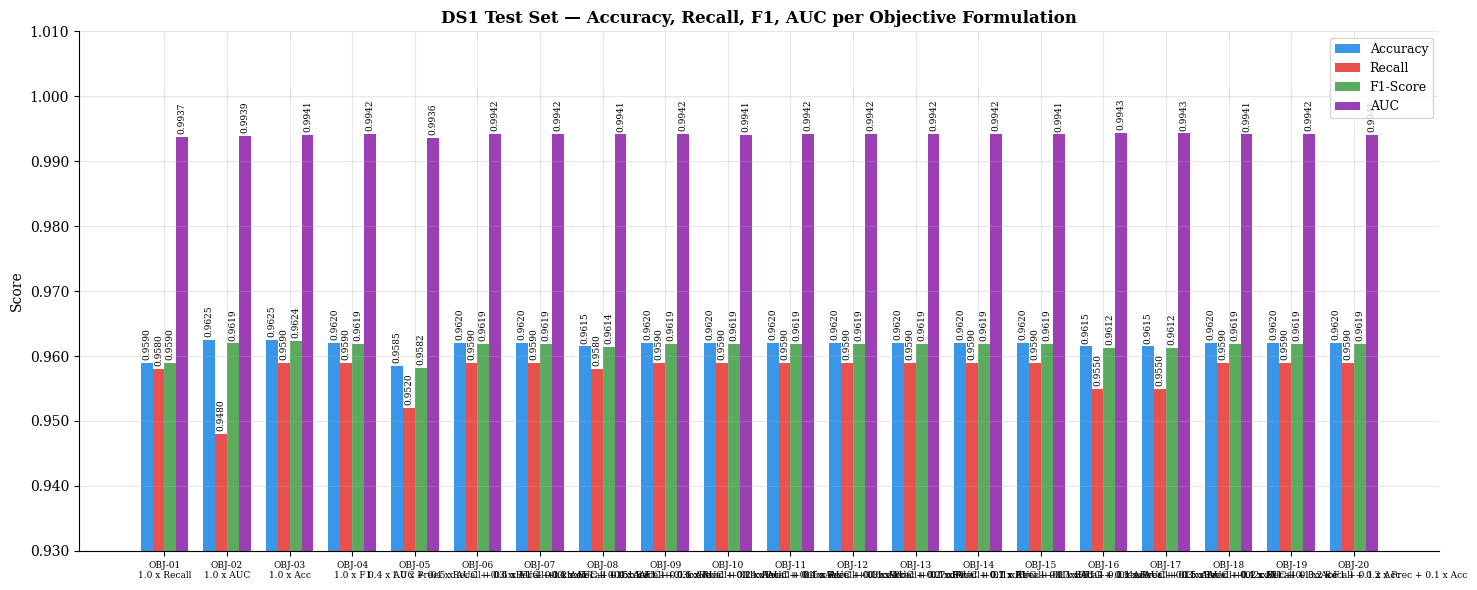

Saved: fig1_ds1_metrics.png


In [9]:
# Figure 1: DS1 metrics — grouped bar chart
obj_ids   = list(all_results.keys())
ds1_acc   = [all_results[o]['ds1']['accuracy']  for o in obj_ids]
ds1_rec   = [all_results[o]['ds1']['recall']    for o in obj_ids]
ds1_f1    = [all_results[o]['ds1']['f1']        for o in obj_ids]
ds1_auc   = [all_results[o]['ds1']['auc']       for o in obj_ids]

x = np.arange(len(obj_ids))
w = 0.19

fig, ax = plt.subplots(figsize=(15, 6))
b1 = ax.bar(x - 1.5 * w, ds1_acc, w, label='Accuracy', color='#1E88E5', alpha=0.88)
b2 = ax.bar(x - 0.5 * w, ds1_rec, w, label='Recall',   color='#E53935', alpha=0.88)
b3 = ax.bar(x + 0.5 * w, ds1_f1,  w, label='F1-Score', color='#43A047', alpha=0.88)
b4 = ax.bar(x + 1.5 * w, ds1_auc, w, label='AUC',      color='#8E24AA', alpha=0.88)

for bars in [b1, b2, b3, b4]:
    ax.bar_label(bars, fmt='%.4f', fontsize=6.5, padding=2, rotation=90)

ax.set_xticks(x)
ax.set_xticklabels(
    [f'{o}\n{all_results[o]["label"]}' for o in obj_ids],
    fontsize=6.5,
)
ax.set_ylim([0.93, 1.01]) # type: ignore
ax.set_ylabel('Score')
ax.set_title(
    'DS1 Test Set — Accuracy, Recall, F1, AUC per Objective Formulation',
    fontweight='bold', fontsize=12,
)
ax.legend(fontsize=9)
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.3f'))
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'fig1_ds1_metrics.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: fig1_ds1_metrics.png')


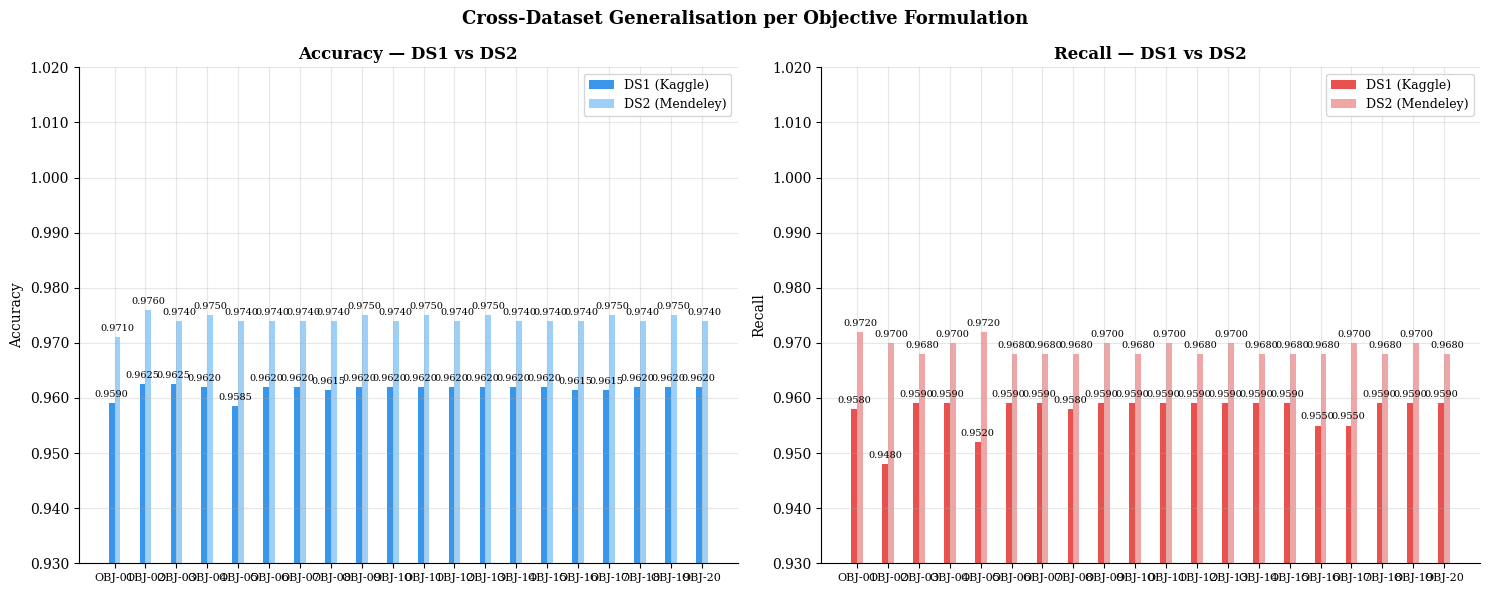

Saved: fig2_ds1_vs_ds2.png


In [10]:
# Figure 2: DS1 vs DS2 — Accuracy and Recall
ds2_acc = [all_results[o]['ds2']['accuracy'] for o in obj_ids]
ds2_rec = [all_results[o]['ds2']['recall']   for o in obj_ids]

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

for ax, ds1_vals, ds2_vals, ylabel, title, c1, c2 in [
    (axes[0], ds1_acc, ds2_acc, 'Accuracy',
     'Accuracy — DS1 vs DS2', '#1E88E5', '#90CAF9'),
    (axes[1], ds1_rec, ds2_rec, 'Recall',
     'Recall — DS1 vs DS2',   '#E53935', '#EF9A9A'),
]:
    b1 = ax.bar(x - w / 2, ds1_vals, w, label='DS1 (Kaggle)',   color=c1, alpha=0.88)
    b2 = ax.bar(x + w / 2, ds2_vals, w, label='DS2 (Mendeley)', color=c2, alpha=0.88)
    for bars in [b1, b2]:
        ax.bar_label(bars, fmt='%.4f', fontsize=7, padding=3)
    ax.set_xticks(x)
    ax.set_xticklabels(obj_ids, fontsize=8)
    ax.set_ylim([0.93, 1.02])
    ax.set_ylabel(ylabel)
    ax.set_title(title, fontweight='bold')
    ax.legend(fontsize=9)
    ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.3f'))

plt.suptitle(
    'Cross-Dataset Generalisation per Objective Formulation',
    fontweight='bold', fontsize=13,
)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'fig2_ds1_vs_ds2.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: fig2_ds1_vs_ds2.png')


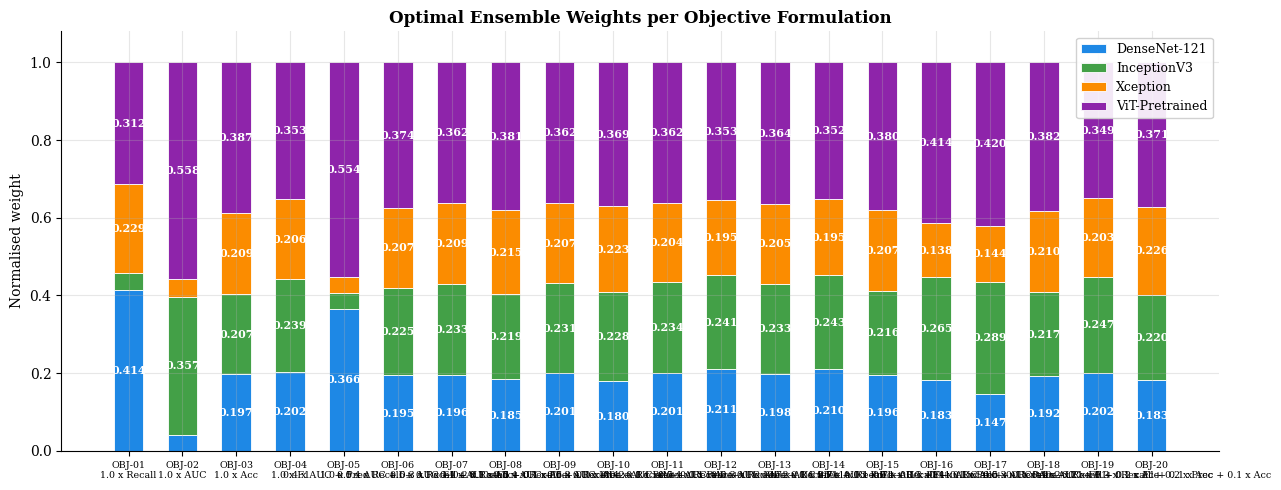

Saved: fig3_ensemble_weights.png


In [11]:
# Figure 3: Ensemble weights per objective — stacked bar
MODEL_COLORS = ['#1E88E5', '#43A047', '#FB8C00', '#8E24AA']

fig, ax = plt.subplots(figsize=(13, 5))
bottoms = np.zeros(len(obj_ids))

for i, arch in enumerate(MODEL_KEYS):
    wvals = np.array([all_results[o]['weights'][arch] for o in obj_ids])
    bars  = ax.bar(
        x, wvals, bottom=bottoms,
        color=MODEL_COLORS[i], label=MODEL_LABELS[arch],
        edgecolor='white', linewidth=0.6, width=0.55,
    )
    for bar, val in zip(bars, wvals):
        if val > 0.06:
            ax.text(
                bar.get_x() + bar.get_width() / 2,
                bar.get_y() + bar.get_height() / 2,
                f'{val:.3f}',
                ha='center', va='center',
                fontsize=8, color='white', fontweight='bold',
            )
    bottoms += wvals

ax.set_xticks(x)
ax.set_xticklabels(
    [f'{o}\n{all_results[o]["label"]}' for o in obj_ids],
    fontsize=6.8,
)
ax.set_ylim(0, 1.08)
ax.set_ylabel('Normalised weight')
ax.set_title(
    'Optimal Ensemble Weights per Objective Formulation',
    fontweight='bold', fontsize=12,
)
ax.legend(loc='upper right', fontsize=9, framealpha=0.9)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'fig3_ensemble_weights.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: fig3_ensemble_weights.png')


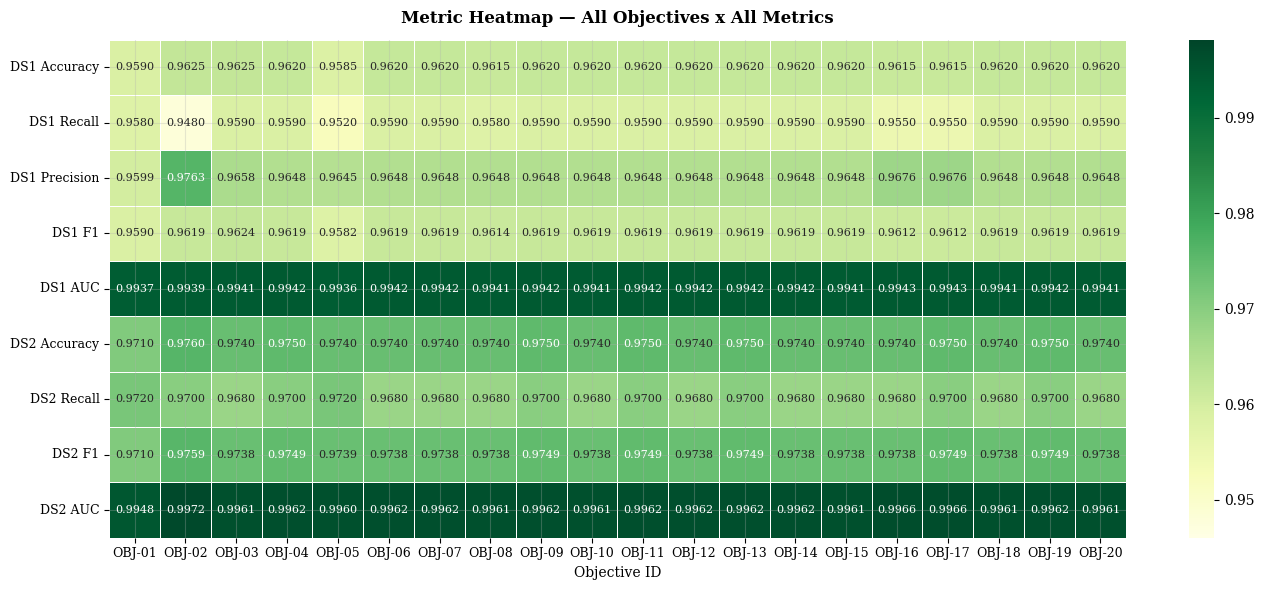

Saved: fig4_heatmap.png


In [12]:
# Figure 4: Heatmap — all metrics across all objectives
heatmap_cols = [
    'DS1 Accuracy', 'DS1 Recall', 'DS1 Precision', 'DS1 F1', 'DS1 AUC',
    'DS2 Accuracy', 'DS2 Recall', 'DS2 F1', 'DS2 AUC',
]
heatmap_data = df[heatmap_cols].T

fig, ax = plt.subplots(figsize=(14, 6))
sns.heatmap(
    heatmap_data,
    annot=True, fmt='.4f', cmap='YlGn',
    linewidths=0.5, linecolor='white',
    vmin=heatmap_data.values.min() - 0.002,
    vmax=heatmap_data.values.max() + 0.001,
    ax=ax,
    annot_kws={'size': 8},
)
ax.set_title(
    'Metric Heatmap — All Objectives x All Metrics',
    fontweight='bold', fontsize=12, pad=12,
)
ax.set_xlabel('Objective ID')
ax.set_ylabel('')
plt.xticks(rotation=0, fontsize=9)
plt.yticks(rotation=0, fontsize=9)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'fig4_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: fig4_heatmap.png')


## 9. Save Results


In [13]:
save_data = {}
for obj_id, res in all_results.items():
    save_data[obj_id] = {
        'label'     : res['label'],
        'best_score': res['best_score'],
        'weights'   : res['weights'],
        'ds1'       : {k: v for k, v in res['ds1'].items() if k != 'conf_mat'},
        'ds2'       : {k: v for k, v in res['ds2'].items() if k != 'conf_mat'},
    }

with open(OUTPUT_DIR / 'all_objectives.json', 'w') as fh:
    json.dump(save_data, fh, indent=2)

print(f'Saved: {OUTPUT_DIR / "all_objectives.json"}')
print(f'\nAll outputs written to: {OUTPUT_DIR}')
print()
for fp in sorted(OUTPUT_DIR.iterdir()):
    if fp.is_file():
        print(f'  {fp.name}')
    elif fp.is_dir():
        print(f'  {fp.name}/')


Saved: D:\Tree-Structured Parzen Estimator\main\testing_variabel\output_test_variabel\all_objectives.json

All outputs written to: D:\Tree-Structured Parzen Estimator\main\testing_variabel\output_test_variabel

  all_objectives.json
  fig1_ds1_metrics.png
  fig2_ds1_vs_ds2.png
  fig3_ensemble_weights.png
  fig4_heatmap.png
  OBJ-01/
  OBJ-02/
  OBJ-03/
  OBJ-04/
  OBJ-05/
  OBJ-06/
  OBJ-07/
  OBJ-08/
  OBJ-09/
  OBJ-10/
  OBJ-11/
  OBJ-12/
  OBJ-13/
  OBJ-14/
  OBJ-15/
  OBJ-16/
  OBJ-17/
  OBJ-18/
  OBJ-19/
  OBJ-20/
  objective_comparison.csv
